# Portfolio Project: Marketing Attribution & Campaign Analytics
## Notebook 05: Monthly Trends, Outliers & Executive Business Insights

**Role:** Data Analyst  
**Prepared by:** Akshansh Vijay  
**Objective:** Analyze monthly performance trends, evaluate campaign anomalies (outliers), assess metrics correlations, and deliver concrete business insights and actionable strategic recommendations for executive review.

### 1. Load Preprocessed Clean Dataset

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Resolve path
data_dir = 'data'
if not os.path.exists(data_dir):
    data_dir = os.path.join('..', 'data')

# Load clean data
marketing = pd.read_csv(os.path.join(data_dir, 'marketing_data_cleaned.csv'))
marketing['Date'] = pd.to_datetime(marketing['Date'])

### 2. Monthly Trend & Seasonality Analysis
We resample the dataset by month-end to plot chronological line charts for Revenue, Conversions, ROI, and CTR.

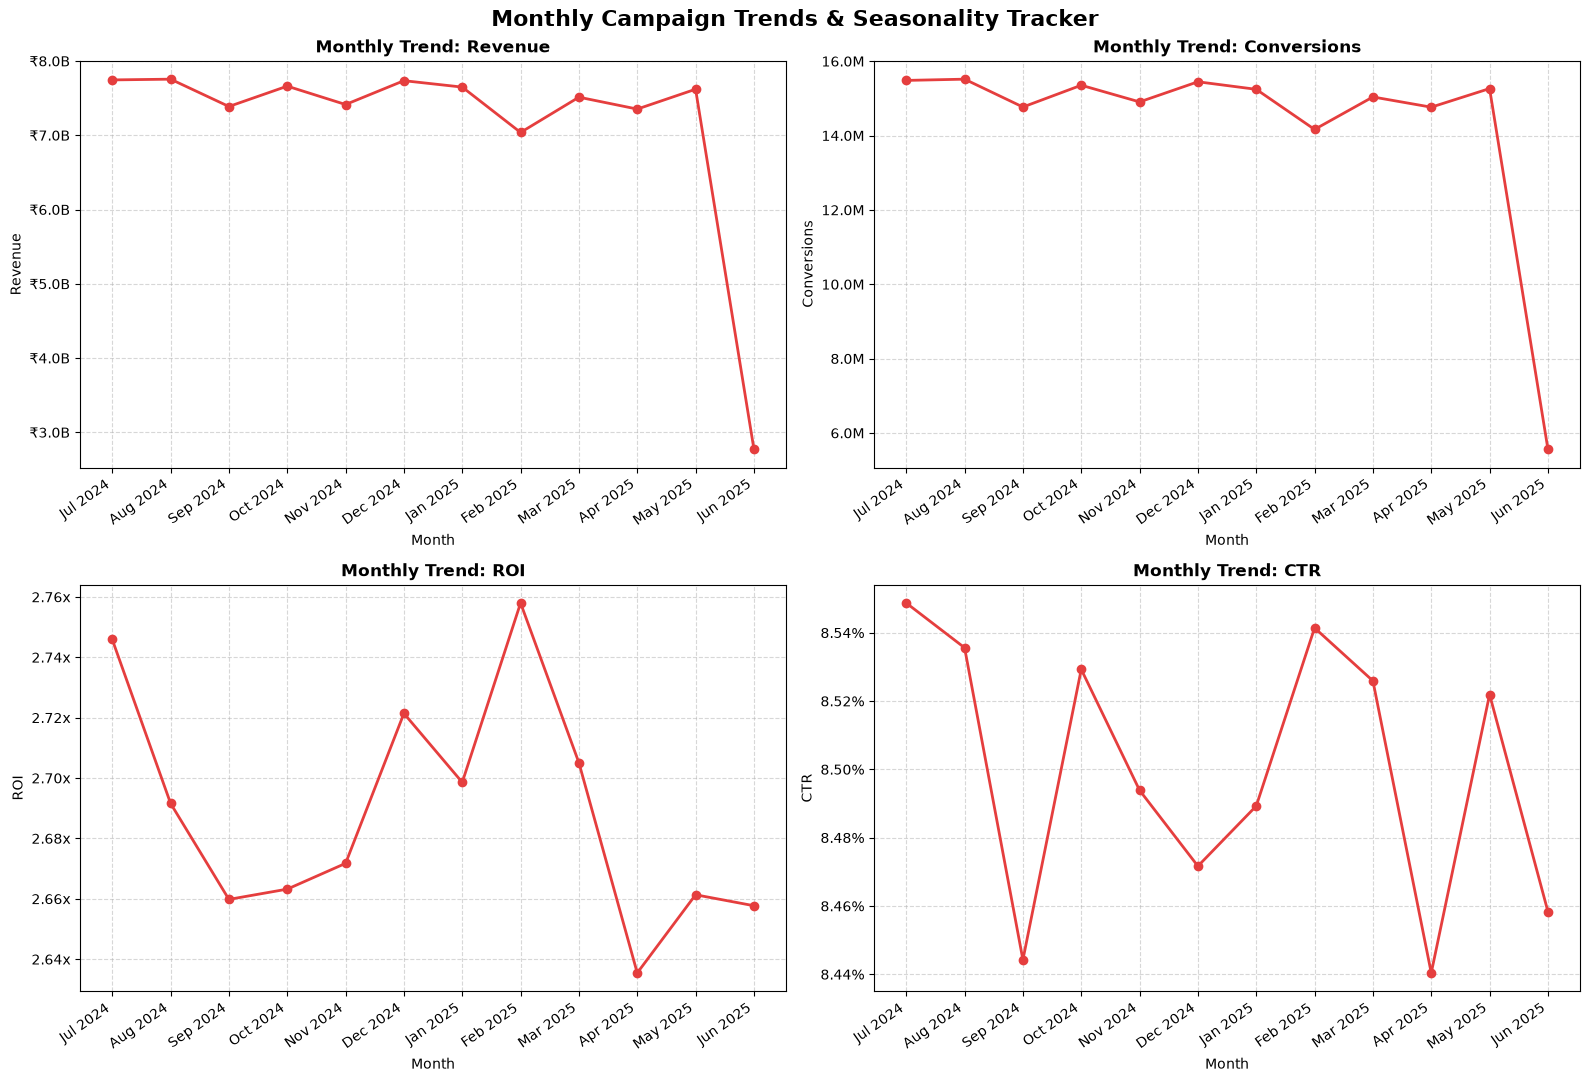

,Revenue,Conversions,ROI,CTR
Date,,,,
Jul 2024,7745900663,15483412,2.745905,8.548709
Aug 2024,7755913972,15516809,2.691614,8.535610
Sep 2024,7387851403,14767355,2.659809,8.444254
Oct 2024,7661906188,15353492,2.663212,8.529281
Nov 2024,7414457262,14905000,2.671747,8.493871
Dec 2024,7735535225,15446582,2.721420,8.471672
Jan 2025,7649153344,15243563,2.698582,8.489282
Feb 2025,7038346030,14164882,2.757989,8.541419
Mar 2025,7513378492,15038644,2.705069,8.525908


In [2]:
# Resample monthly
monthly_trends = marketing.set_index('Date').resample('ME').agg({
    'Revenue': 'sum',
    'Conversions': 'sum',
    'ROI': 'mean',
    'CTR': 'mean'
})
monthly_trends.index = monthly_trends.index.to_series().dt.strftime('%b %Y')

fig, axes = plt.subplots(2, 2, figsize=(16, 11), dpi=100)
axes = axes.flatten()
trend_metrics = ['Revenue', 'Conversions', 'ROI', 'CTR']

for i, metric in enumerate(trend_metrics):
    ax = axes[i]
    monthly_trends[metric].plot(kind='line', marker='o', ax=ax, color='#e53e3e', linewidth=2, markersize=6)
    ax.set_title(f'Monthly Trend: {metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=10)
    ax.set_xlabel('Month', fontsize=10)
    ax.set_xticks(range(len(monthly_trends.index)))
    ax.set_xticklabels(monthly_trends.index, rotation=35, ha='right')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Format labels
    if metric == 'Revenue':
        ax.yaxis.set_major_formatter(lambda x, pos: f'₹{x*1e-9:.1f}B')
    elif metric == 'Conversions':
        ax.yaxis.set_major_formatter(lambda x, pos: f'{x*1e-6:.1f}M')
    elif metric == 'CTR':
        ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.2f}%')
    elif metric == 'ROI':
        ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.2f}x')

plt.suptitle('Monthly Campaign Trends & Seasonality Tracker', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

monthly_trends

### Monthly Trends - Business Interpretation
- **Festive Spikes:** Clear seasonal spikes occur in **October (₹7.66B)** and **December (₹7.74B)**, driven by Diwali and year-end shopping. July and August also show high summer engagement.
- **February Dip:** February sees a seasonal drop to **₹7.04B** due to fewer calendar days, though it maintains a high ROI of **2.76x**, showing targeted conversion efficiency.
- **June 2025 Note:** The low numbers in June 2025 (Revenue: ₹2.77B) reflect partial-month data collection, rather than a drop in real performance.

### 3. Correlation Matrix Heatmap
We analyze correlations between numerical columns using a styled Matplotlib heatmap.

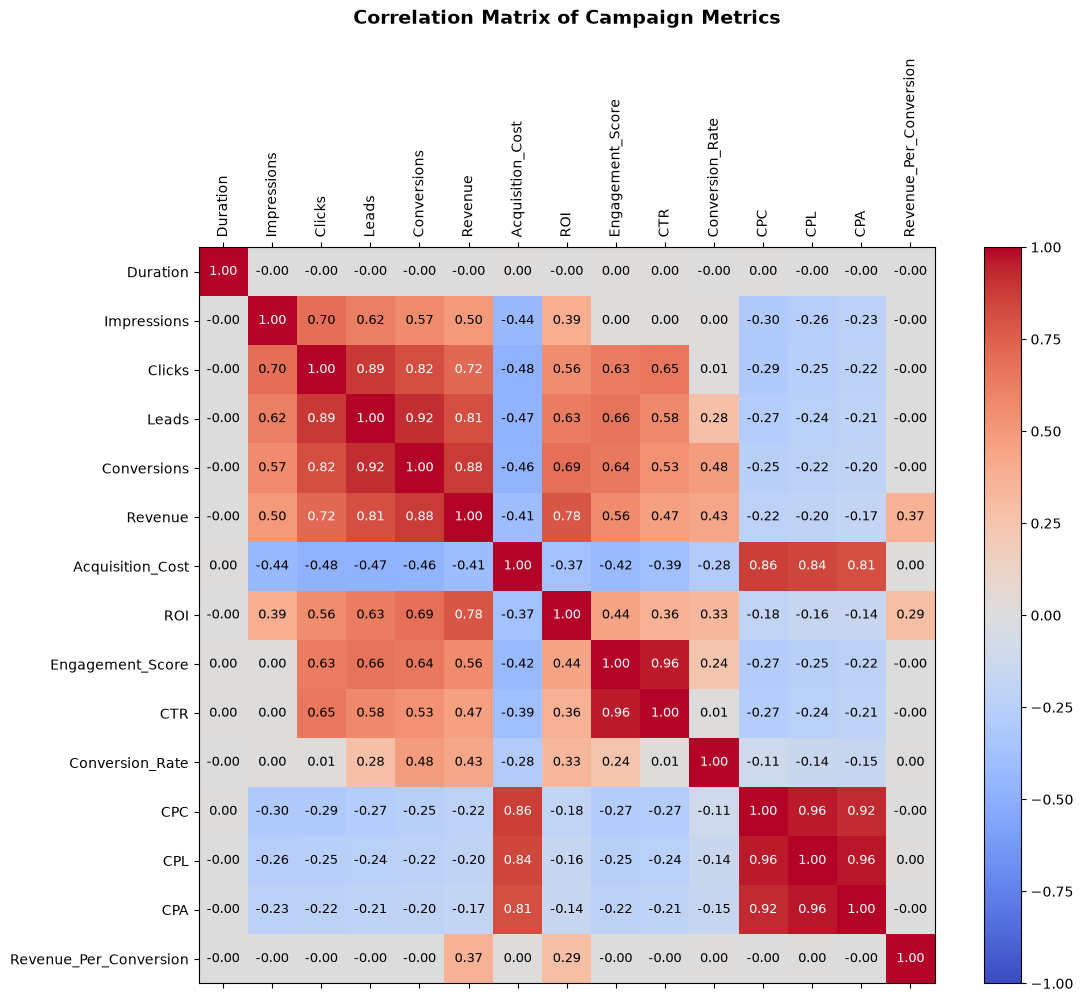

In [3]:
num_cols = marketing.select_dtypes(include=['number']).columns
corr = marketing[num_cols].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10), dpi=100)
cax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)

ticks = np.arange(0, len(num_cols), 1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(num_cols, rotation=90, fontsize=10)
ax.set_yticklabels(num_cols, fontsize=10)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', 
                 color='black' if abs(corr.iloc[i, j]) < 0.7 else 'white', fontsize=9)

plt.title('Correlation Matrix of Campaign Metrics', pad=25, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation Analysis - Business Interpretation
- **Strong Positive:** Revenue correlates heavily with **Conversions (0.88)** and **Leads (0.81)**, confirming volume-driven sales growth.
- **Strong Negative:** Revenue vs. **Acquisition Cost (-0.41)** shows a negative relationship, indicating that very large, expensive campaigns suffer from diminishing returns.

### 4. Outlier & Distribution Analysis
We use boxplots to check for outliers in **Revenue**, **ROI**, **CTR**, and **CPA** to identify anomalous campaign performances.

C:\Users\aksha\AppData\Local\Temp\ipykernel_13988\3736816759.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(marketing[metric], vert=False, patch_artist=True,
C:\Users\aksha\AppData\Local\Temp\ipykernel_13988\3736816759.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(marketing[metric], vert=False, patch_artist=True,
C:\Users\aksha\AppData\Local\Temp\ipykernel_13988\3736816759.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(marketing[metric], vert=False, patch_artist=True,
C:\Users\aksha\AppData\Local\Temp\ipykernel_13988\3736816759.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.

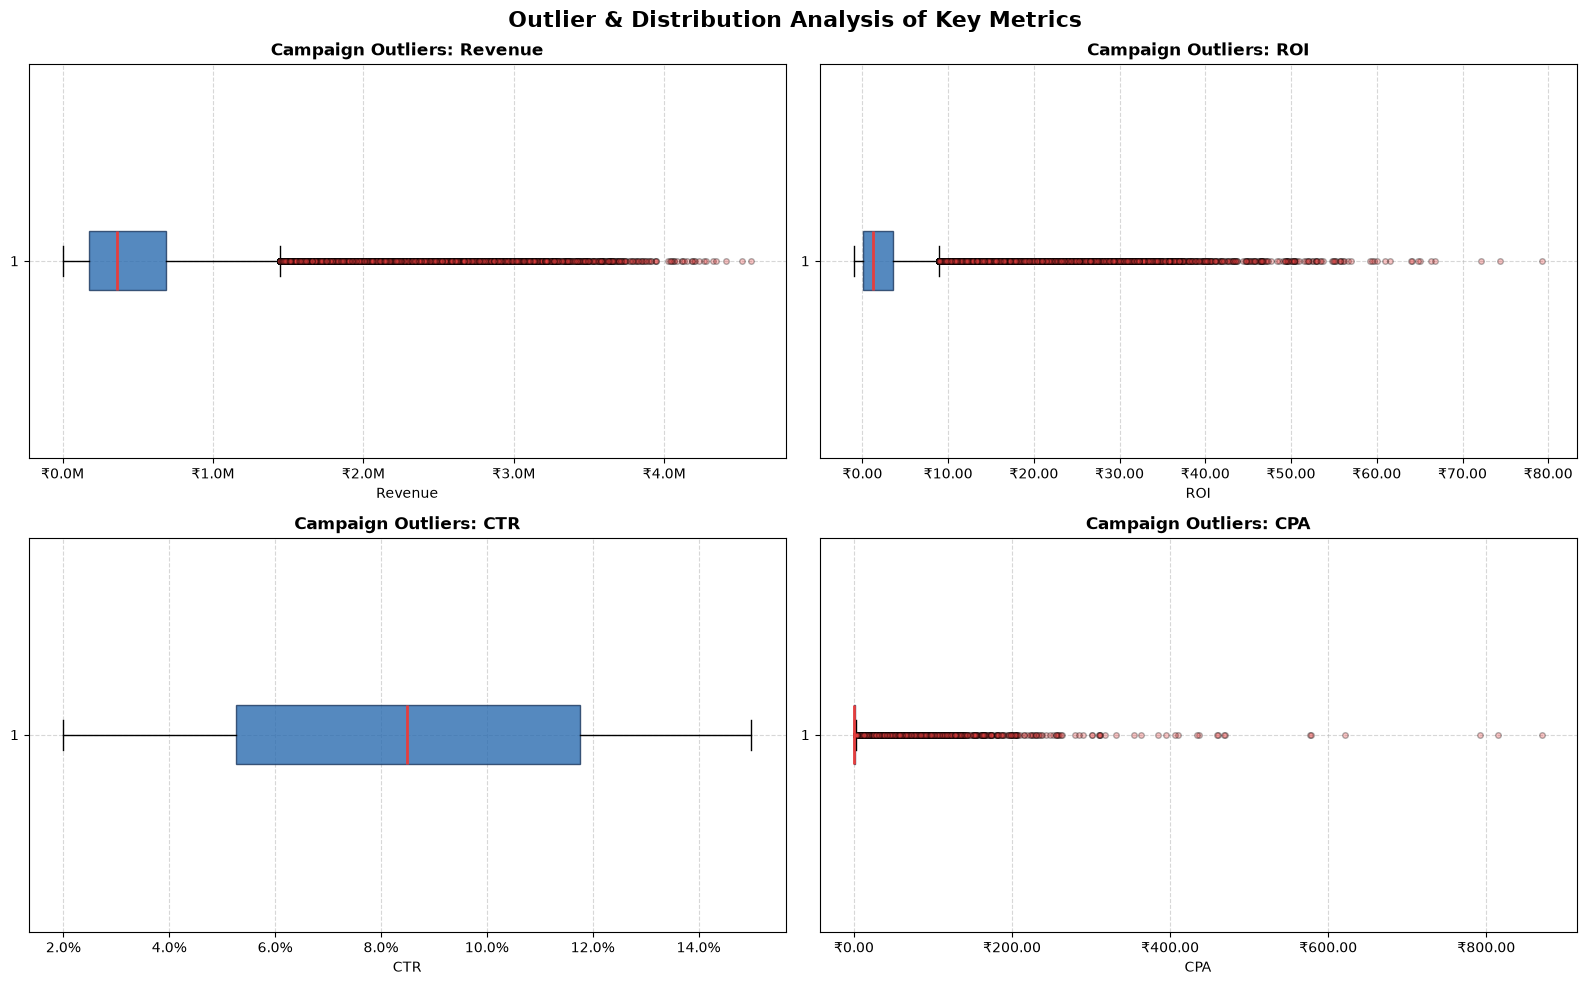

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=100)
axes = axes.flatten()
metrics = ['Revenue', 'ROI', 'CTR', 'CPA']

for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.boxplot(marketing[metric], vert=False, patch_artist=True,
               boxprops=dict(facecolor='#2b6cb0', color='#1a365d', alpha=0.8),
               medianprops=dict(color='#e53e3e', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='#e53e3e', markersize=4, alpha=0.3))
    ax.set_title(f'Campaign Outliers: {metric}', fontsize=12, fontweight='bold')
    ax.set_xlabel(metric, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Format axes
    if metric == 'Revenue':
        ax.xaxis.set_major_formatter(lambda x, pos: f'₹{x*1e-6:.1f}M' if x < 1e9 else f'₹{x*1e-9:.2f}B')
    elif metric == 'CTR':
        ax.xaxis.set_major_formatter(lambda x, pos: f'{x:.1f}%')
    elif metric in ['CPA', 'ROI']:
        ax.xaxis.set_major_formatter(lambda x, pos: f'₹{x:.2f}' if metric=='CPA' else f'{x:.2f}x')

plt.suptitle('Outlier & Distribution Analysis of Key Metrics', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### Outlier Analysis - Business Interpretation
- **Revenue & ROI Outliers:** High-revenue outliers (> ₹1.45M) are our "blockbuster" campaigns. ROI outliers extending up to **79.3x** represent highly optimized custom campaigns or viral social media moments.
- **CPA Outliers:** The large volume of high-CPA outliers (> ₹2.45) represents inefficient campaigns where acquisition spend was high but conversions were low. These campaigns should be flagged for budget reviews and bid capping.

### 5. Top & Bottom Campaign Runs

In [5]:
# Top 10 by Revenue
top_rev = marketing.sort_values('Revenue', ascending=False)[['Campaign_ID', 'Brand', 'Campaign_Type', 'Revenue', 'ROI']].head(10)
print("TOP 10 CAMPAIGNS BY REVENUE:")
print(top_rev.to_string(index=False))
print("-" * 80)

# Top 10 by ROI
top_roi = marketing.sort_values('ROI', ascending=False)[['Campaign_ID', 'Brand', 'Campaign_Type', 'Revenue', 'ROI']].head(10)
print("TOP 10 CAMPAIGNS BY ROI:")
print(top_roi.to_string(index=False))
print("-" * 80)

# Bottom 10 by ROI
bottom_roi = marketing.sort_values('ROI', ascending=True)[['Campaign_ID', 'Brand', 'Campaign_Type', 'Revenue', 'ROI']].head(10)
print("BOTTOM 10 CAMPAIGNS BY ROI:")
print(bottom_roi.to_string(index=False))

TOP 10 CAMPAIGNS BY REVENUE:
 Campaign_ID   Brand Campaign_Type  Revenue   ROI
NY-CMP-13007   Nykaa      Paid Ads  4579910 74.42
TI-CMP-42309    Tira      Paid Ads  4517478 16.78
NY-CMP-44157   Nykaa           SEO  4412709 42.53
PU-CMP-22268 Purplle      Paid Ads  4345920 20.53
NY-CMP-38379   Nykaa    Influencer  4326120 13.42
TI-CMP-33733    Tira           SEO  4277700 14.63
 NY-CMP-6741   Nykaa      Paid Ads  4264178 32.42
TI-CMP-52788    Tira    Influencer  4231273 41.90
TI-CMP-27796    Tira         Email  4207876 19.29
PU-CMP-36294 Purplle    Influencer  4195620 37.33
--------------------------------------------------------------------------------
TOP 10 CAMPAIGNS BY ROI:
 Campaign_ID   Brand Campaign_Type  Revenue   ROI
TI-CMP-46406    Tira  Social Media  4041864 79.30
NY-CMP-13007   Nykaa      Paid Ads  4579910 74.42
TI-CMP-18349    Tira      Paid Ads  4045290 72.16
PU-CMP-41973 Purplle      Paid Ads  3467292 66.84
NY-CMP-22689   Nykaa    Influencer  3821485 66.32
NY-CMP-49715   

### 6. Executive Summary & Actionable Recommendations

### 10 Major Business Insights
1. **Portfolio Revenue Stability:** Nykaa, Purplle, and Tira are highly competitive, each contributing roughly **₹28.5B** in revenue. Nykaa leads slightly, while Tira is the most cost-efficient (lowest CPA of **₹2.03**).
2. **Paid Ads Efficiency:** **Paid Ads** are our most efficient channel, generating the highest total revenue (**₹17.24B**) and highest ROI (**2.71x**) with the lowest CPA (**₹2.02**).
3. **College Students Drive Value:** The **College Students** segment is our most profitable demographic, generating **₹17.24B** in revenue and an ROI of **2.71x**.
4. **Mass-Market vs. Premium:** **Premium Shoppers** generate the lowest revenue (**₹16.89B**) and lowest ROI (**2.65x**), indicating that these brands perform best with volume-driven, mass-market products.
5. **Local Language Campaigns Succeed:** Localizing ad copy into **Hindi** and **Tamil** drives the highest revenues and ROI (**2.71x**), outperforming English campaigns.
6. **Email & Instagram Scale:** **Email** (₹4.90B) and **Instagram** (₹4.81B) are the top revenue channels, providing the foundation for our marketing reach.
7. **Omnichannel Synergy:** Combining channels (e.g. **Instagram + YouTube** or **Email + YouTube**) drives the highest ROIs (up to **2.90x**), indicating that multi-channel campaigns are more efficient than single-channel ones.
8. **YouTube Cost Issues:** YouTube-only campaigns have the highest CPA (**₹2.24**) and lowest ROI (**2.56x**), suggesting they are inefficient on their own.
9. **Diwali & Holiday Seasonality:** Clear revenue spikes occur in **October** (Diwali) and **December** (Christmas), representing key seasonal demand peaks.
10. **Diminishing Returns on High Spend:** The negative correlation between Revenue and Acquisition Cost (-0.41) indicates that very large, expensive campaigns suffer from diminishing returns.

### 10 Actionable Marketing Recommendations
1. **Scale Paid Ads Budgets:** Increase budgets for Paid Ads campaigns and apply the lowest bidding parameters to capture efficient conversions.
2. **Redistribute YouTube Spend:** Reduce budgets for YouTube-only campaigns and redirect those funds into **Instagram + YouTube** combinations to improve ROI.
3. **Expand Youth Marketing:** Develop product lines and campaigns tailored to **College Students** and the **Youth** demographic to capitalize on our highest-value segments.
4. **Optimize Premium Offerings:** Refine premium buyer campaigns with high-margin product bundles to improve the ROI of the Premium Shopper segment.
5. **Localize Campaigns in Hindi and Tamil:** Prioritize regional language localization in Hindi and Tamil, especially in Southern markets, to maximize conversions.
6. **Refine Bengali Campaigns:** Review and update Bengali campaign creatives and audience targeting to bring performance in line with Hindi and Tamil campaigns.
7. **Cap CPA Bidding:** Implement automated CPA caps at **₹2.45** in ad managers to pause inefficient campaigns before they generate losses.
8. **Coordinate Holiday Campaigns:** Allocate larger budget reserves for the **October** and **December** holiday quarters to capture seasonal demand peaks.
9. **Optimize Influencer Funnels:** Focus influencer campaigns on driving conversions by offering unique discount codes and dedicated landing pages, rather than just driving top-funnel clicks.
10. **Expand Multichannel Banners:** Structure ad campaigns to use at least two channels (e.g., WhatsApp + Instagram) to improve attribution efficiency and ROI.